<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"></ul></div>

In [2]:
import pandas as pd
import scipy.stats as stats
# 1. 데이터 불러오기 및 집단 분리
df = pd.read_csv('https://raw.githubusercontent.com/ADPclass/ADP_book_ver01/main/data/delivery_data.csv') 

a_time = df[df['company'] =='A']['delivery_time']
b_time = df[df['company'] =='B']['delivery_time']
c_time = df[df['company'] =='C']['delivery_time']
# 2. 정규성 검정 (Shapiro)
print("A사 정규성 p-value:", stats.shapiro(a_time).pvalue)
print("B사 정규성 p-value:", stats.shapiro(b_time).pvalue)
print("C사 정규성 p-value:", stats.shapiro(c_time).pvalue)
# 3. 등분산성 검정 (Levene)
# 모든 집단의 분산이 같은지 확인합니다.
stat, p_levene = stats.levene(a_time, b_time, c_time)
print(f"등분산성 검정 p-value: {p_levene:.4f}")


A사 정규성 p-value: 0.667159914970398
B사 정규성 p-value: 3.4109859825548483e-07
C사 정규성 p-value: 0.9314041137695312
등분산성 검정 p-value: 0.3136


In [3]:
import pandas as pd
import scipy.stats as stats
from statsmodels.stats.multicomp import MultiComparison

# 1. 정규성이 깨졌으므로 비모수 검정(Kruskal-Wallis) 실시
# scipy.stats는 pandas-flavor를 쓰지 않아 에러가 나지 않습니다.
stat, p_val = stats.kruskal(a_time, b_time, c_time)
print(f"Kruskal-Wallis 검정 결과 p-value: {p_val:.4f}")

# 2. 사후검정 (pingouin 대신 statsmodels 활용)
# 이 방식이 Pandas 1.1.2 환경에서 가장 안정적입니다.
mc = MultiComparison(df['delivery_time'], df['company'])

# 모든 조합에 대해 Mann-Whitney U 검정 실시 (본페로니 교정 적용)
result = mc.allpairtest(stats.mannwhitneyu, method='bonf')

# 결과 테이블 확인
print(result[0])

Kruskal-Wallis 검정 결과 p-value: 0.0000
Test Multiple Comparison mannwhitneyu 
FWER=0.05 method=bonf
alphacSidak=0.02, alphacBonf=0.017
group1 group2  stat   pval  pval_corr reject
--------------------------------------------
     A      B  166.0    0.0       0.0   True
     A      C 1682.0 0.0029    0.0088   True
     B      C 2433.0    0.0       0.0   True
--------------------------------------------


In [4]:
# 각 그룹별 평균(mean)과 중앙값(median) 확인
# 이 수치를 봐야 누가 얼마나 더 우수한지 정확히 알 수 있습니다.
print(df.groupby('company')['delivery_time'].agg(['mean', 'median']))

               mean      median
company                        
A        134.704857  134.544704
B        155.827961  154.590589
C        127.579636  128.038281


In [5]:
## 이원배치분산분석 

In [6]:
## 참고 ## 정규성, 등분산성 검정하는 방법 
import pandas as pd
import scipy.stats as stats

# 1. 조합별 정규성 검정 (Shapiro-Wilk)
print("## 조합별 정규성 검정 결과 ##")
for (comp, loc), group in df.groupby(['company', 'area']):
    p_val = stats.shapiro(group['delivery_time']).pvalue
    print(f"[{comp} - {loc}] p-value: {p_val:.4f}")

# 2. 모든 조합간 등분산성 검정 (Levene)
groups = [group['delivery_time'] for _, group in df.groupby(['company', 'area'])]
print(f"\n등분산성 p-value: {stats.levene(*groups).pvalue:.4f}")

## 조합별 정규성 검정 결과 ##
[A - Rural] p-value: 0.0316
[A - Urban] p-value: 0.0480
[B - Rural] p-value: 0.9609
[B - Urban] p-value: 0.0000
[C - Rural] p-value: 0.1716
[C - Urban] p-value: 0.1409

등분산성 p-value: 0.0011


                          sum_sq     df           F        PR(>F)
C(company)          21567.052411    2.0  127.052065  1.593450e-32
C(area)                 0.000351    1.0    0.000004  9.983796e-01
C(company):C(area)   6646.580517    2.0   39.155178  2.636340e-14
Residual            12221.979847  144.0         NaN           NaN


C:\Users\jjang\anaconda3\envs\adp_final\lib\site-packages\matplotlib\cbook\__init__.py:1377: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
C:\Users\jjang\anaconda3\envs\adp_final\lib\site-packages\matplotlib\axes\_base.py:237: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]
C:\Users\jjang\anaconda3\envs\adp_final\lib\site-packages\matplotlib\axes\_base.py:239: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


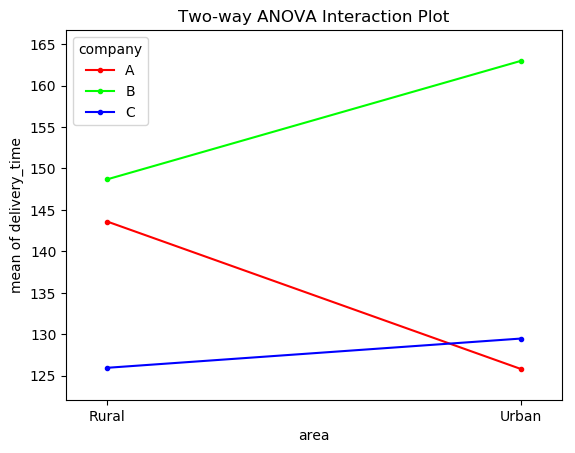

In [7]:
import pandas as pd
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.graphics.factorplots import interaction_plot
import matplotlib.pyplot as plt

# 1. 데이터 로드 (company: A/B/C, area: 도심/외곽 데이터가 있다고 가정)
df = pd.read_csv('./data/delivery_data.csv')

# 2. 모델 구축: 'C()'는 범주형 변수 명시, '*'는 교호작용 포함을 의미
model = ols('delivery_time ~ C(company) * C(area)', data=df).fit()

# 3. ANOVA 테이블 출력 (typ=2는 시험장 표준)
aov_table = anova_lm(model, typ=2)
print(aov_table)

# 4. 교호작용 그래프 시각화 (해석의 핵심!)
fig = interaction_plot(x=df['area'], trace=df['company'], response=df['delivery_time'])
plt.title('Two-way ANOVA Interaction Plot')
plt.show()